In [1]:
import os
os.chdir('../../')

[Plot] s3 :: logs/dit/mobile/s3/step_00020000.pt


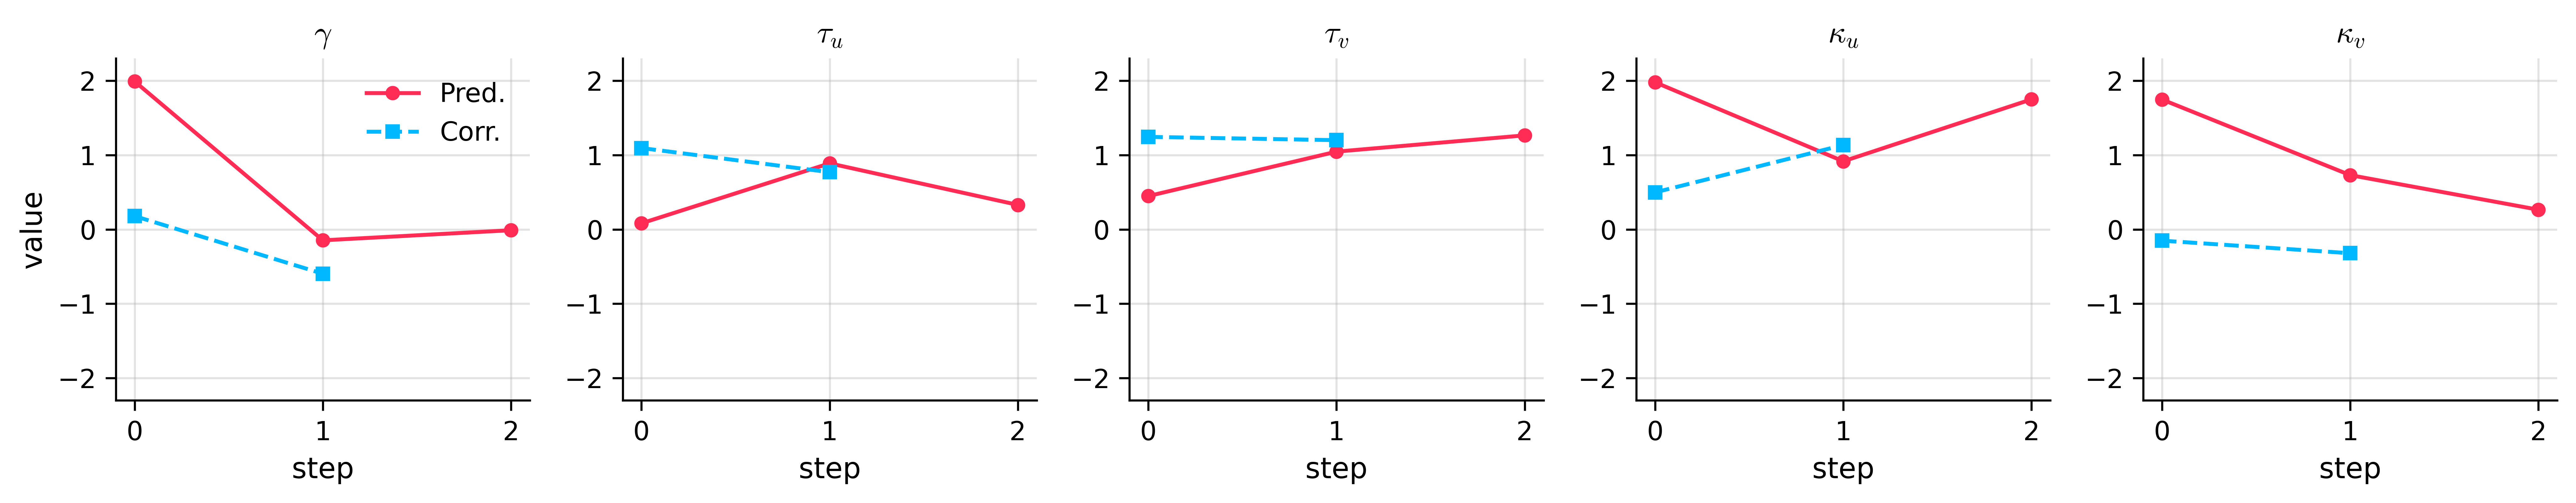

[Plot] s5 :: logs/dit/mobile/s5/step_00020000.pt


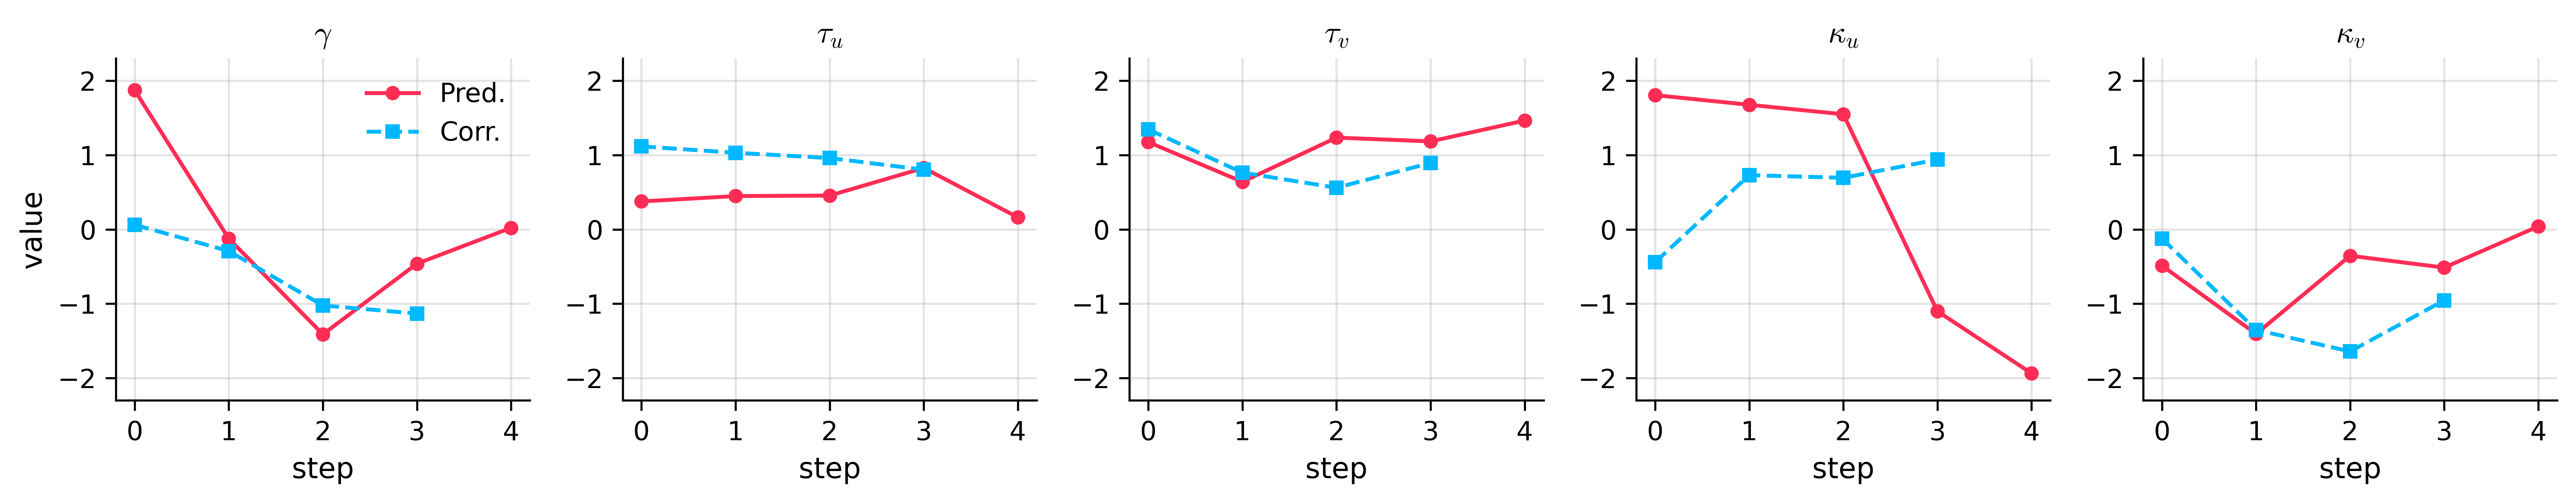

[Plot] s7 :: logs/dit/mobile/s7/step_00020000.pt


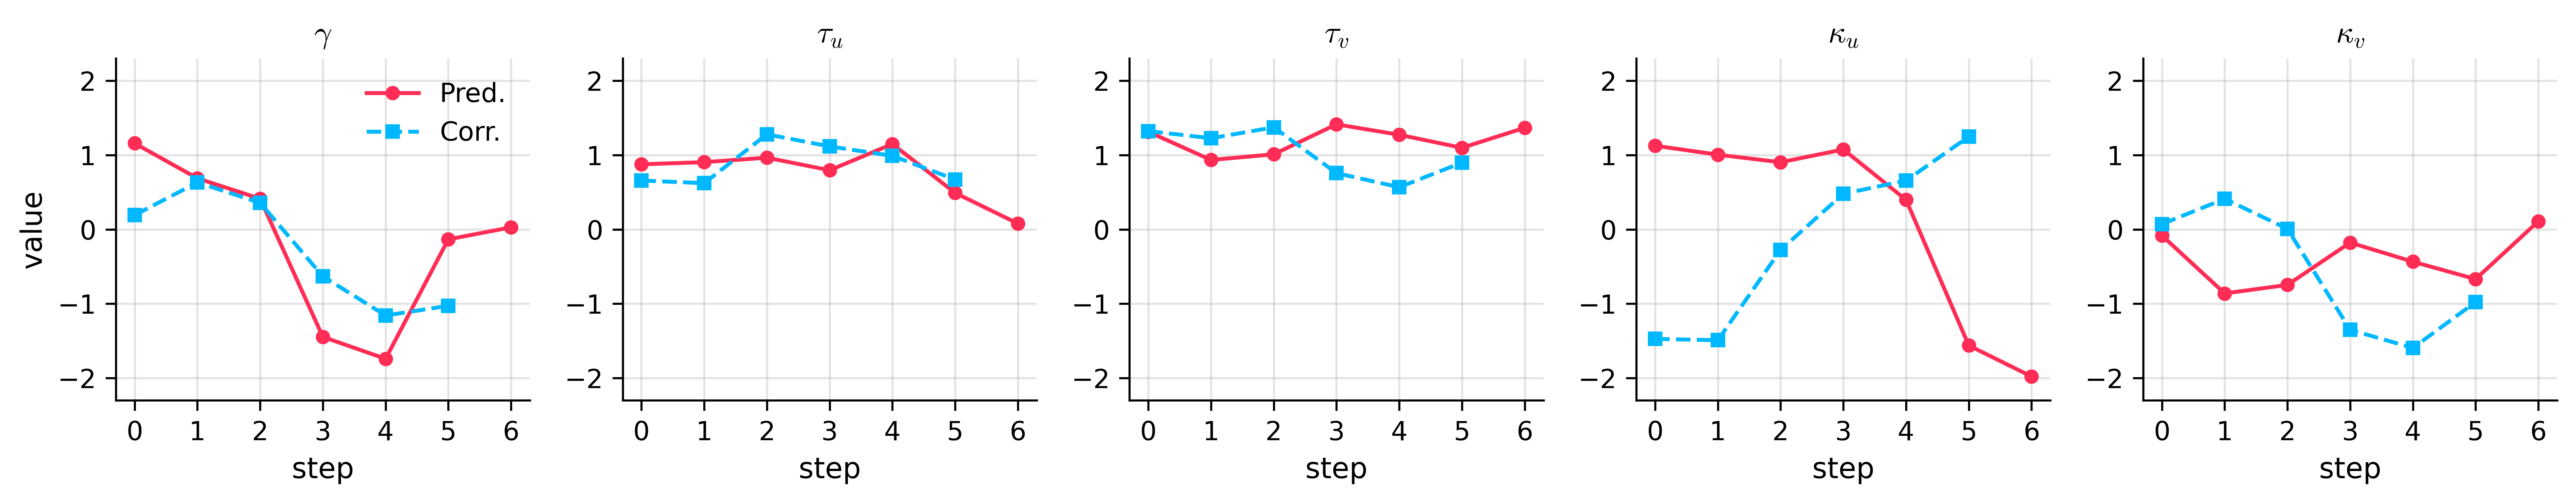

[Plot] s9 :: logs/dit/mobile/s9/step_00020000.pt


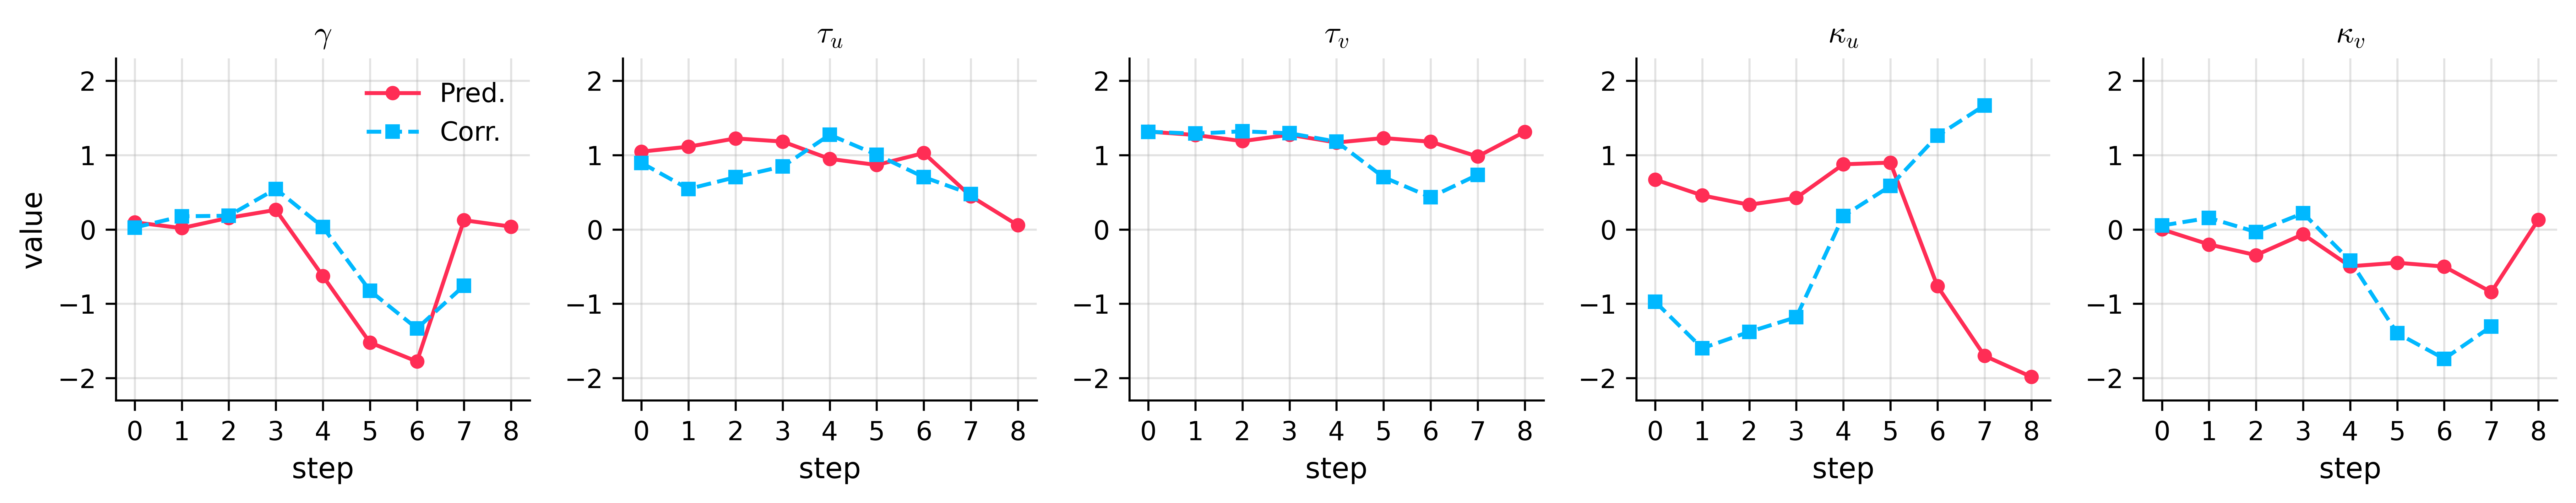

In [3]:
import numpy as np
import scipy 

# Minimal change: keep your plotting logic identical, only loop over s3/s5/s7/s9.
import torch, numpy as np, matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ---------- Palettes & colors (unchanged) ----------
PALETTES = [
    ["#FF2D55", "#00B8FF", "#00E676"],
    ["#1f77b4", "#ff7f0e", "#2ca02c"],  # Classic Blue–Orange–Green
    ["#d62728", "#1f77b4", "#7f7f7f"],  # Muted Red–Blue–Gray
    ["#4c78a8", "#f58518", "#54a24b"],  # Vega-Altair Set
    ["#2b83ba", "#abdda4", "#fdae61"],  # Nature Inspired
    ["#e69f00", "#56b4e9", "#009e73"],  # CUD (color-blind friendly)
    ["#377eb8", "#e41a1c", "#4d4d4d"],  # Cool–Warm–Neutral
    ["#8c510a", "#01665e", "#f5f5f5"],  # Earth Tone
    ["#e41a1c", "#377eb8", "#4daf4a"],  # Bold & Bright
    ["#984ea3", "#ff7f00", "#66a61e"],  # Dark Pastel
    ["#000000", "#7f7f7f", "#e6e6e6"],  # Grayscale Emphasis
]
PALETTE_INDEX = 0
PRED_COLOR = PALETTES[PALETTE_INDEX][0]
CORR_COLOR = PALETTES[PALETTE_INDEX][1]

# ---------- Style (ICLR-ready, unchanged) ----------
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,                    # 본문 크기
    "axes.titlesize": 12,               # 서브플롯 제목
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8,
    "grid.alpha": 0.35,
    "mathtext.fontset": "cm",           # Computer Modern 수학 폰트
})

# (index, title, transform, refline) — unchanged
params = [
    (0, r'$\gamma$',  lambda a: np.tanh(a)*2.,          0.0),
    (1, r'$\tau_u$',  lambda a: scipy.special.softplus(1.0 + a),    1.0),
    (2, r'$\tau_v$',  lambda a: scipy.special.softplus(1.0 + a),    1.0),
    (3, r'$\kappa_u$',lambda a: np.tanh(a)*2,          0.0),
    (4, r'$\kappa_v$',lambda a: np.tanh(a)*2,          0.0),
]
lw = 1.5
ms = 4.5

def render(PATH):
    obj = torch.load(PATH, map_location='cpu')
    tab = obj['solver_state_dict']['param_extractor.table'].float().numpy()  # [S,2,P]
    x   = np.arange(tab.shape[0])  # 0..S-1 (step index)

    fig, ax = plt.subplots(1, 5, figsize=(13.8, 2.8), sharex=True, dpi=600)  # unchanged

    for k, (idx, title, f, refline) in enumerate(params):
        pred = f(tab[:, 0, idx])
        corr_full = f(tab[:, 1, idx])

        # corr는 한 칸 당겨 정렬(corr[1:]) + 마지막 step은 아예 그리지 않음 — unchanged
        corr_shift = corr_full[1:]      # 길이: S-1
        x_corr     = x[:-1]             # 길이: S-1

        # 데이터 기반 여백 있는 y-범위 (마지막 corr 점 제외한 값으로 계산) — unchanged
        y = np.concatenate([pred, corr_shift])
        ypad = 0.08 * (np.nanmax(y) - np.nanmin(y) + 1e-9)
        ymin, ymax = np.nanmin(y) - ypad, np.nanmax(y) + ypad

        ax[k].plot(x,       pred, '-',  marker='o', ms=ms, lw=lw, label='Pred.', color=PRED_COLOR)
        ax[k].plot(x_corr,  corr_shift, '--', marker='s', ms=ms, lw=lw, label='Corr.', color=CORR_COLOR)

        ax[k].set_title(title, pad=6)
        ax[k].set_ylim(-2.3, 2.3)  # unchanged fixed range
        ax[k].set_xlabel('step')
        ax[k].xaxis.set_major_locator(MaxNLocator(integer=True))
        ax[k].grid(True, which='major')
        ax[k].tick_params(direction='out', length=4, width=0.8)
        for spine in ['top', 'right']:
            ax[k].spines[spine].set_visible(False)

    # 왼쪽 첫 축에만 y라벨 — unchanged
    ax[0].set_ylabel('value')

    # 범례: 첫 축에만, 프레임 제거 — unchanged
    ax[0].legend(loc='best', frameon=False, ncols=1)

    fig.tight_layout(w_pad=1.2)
    plt.show()

# ---------- Loop over s3, s5, s7, s9 (ONLY addition) ----------
for S in (3, 5, 7, 9):
    PATH = f'logs/dit/mobile/s{S}/step_00020000.pt'
    try:
        print(f"[Plot] s{S} :: {PATH}")
        render(PATH)
    except FileNotFoundError as e:
        print(f"[Skip] s{S} not found: {e}")
    except KeyError as e:
        print(f"[Skip] s{S} missing expected key: {e}")
    except Exception as e:
        print(f"[Skip] s{S} error: {type(e).__name__}: {e}")
